# Betingede funksjoner med arrays

**Læringsmål:**

- Betingelser
- For-løkker
- Funksjoner
- Elementvise operasjoner med arrays/lister

### Oppsummering betingede funksjoner

I øving 3 så vi på bruk av if-setinger til å regne på betingede funksjoner (som f.eks. `abs(x)`). I denne oppgaven skal vi se nærmere på bruk av beslutninger på alle elementene i en array.

Først importerer vi biblioteket, `numpy` som vi kommer til å benytte til matematiske beregninger i denne oppgaven. 

In [1]:
import numpy as np

I den matematiske verden er det en rekke funksjoner som har ulike funksjonsuttrykk for ulike input-verdier. Den naturlige logaritmen $ln(x)$ er definert for alle reelle verdier større enn 0. Dette kan skrives som følger:

$ g(x) = \begin{cases} \ln(x), \text{ if } x > 0\\ \text{undef.}, \text{ if } x \leqslant 0 \end{cases}$

I Python kan vi håndtere dette ved å undersøke hvilken input som gis til funksjonen, og returnere den riktige verdien, slik det er gjort i eksempelet nedenfor.

In [2]:
def g(x):
    if x <= 0:
        return float("NaN") # NaN står for "Not A Number", og brukes når resultatet av en utregning er et tall som ikke eksisteres.
    return np.log(x)

In [3]:
# Dersom vi gir en negativ verdi som input, forventer vi tom output
g(-2)

nan

In [4]:
# Dersom vi gir en positiv verdi, forventer vi at denne skal være lik den naturlige logaritmen som output
g(np.e)

1.0

### Betingede funksjoner med array som input

Som kjent er **if**-setninger dårlig egnet til å håndtere arrays, og dersom vi ønsker å regne ut $f(x)$ for alle verdiene i en array må vi benytte en løkke. Nedenfor modifiserer vi funksjonen $f(x)$ slik at den kan brukes med arrays som input.

In [5]:
def g(x_array):
    y_list = []  # Forbered en tom liste som skal holde alle verdiene y = f(x)
    for x in x_array:
        if x <= 0:
            y = float("NaN")
        else:
            y = np.log(x)
        y_list.append(y)
    return np.array(y_list)

Forklaringen av funksjonens innhold er som følger:
1. Lag en "tom" liste `y_list`. Denne skal etter hvert inneholde funksjonsverdiene $f(x)$ for alle verdiene i `x_array` når løkken er ferdig.
    * Vi bruker en liste og ikke en array for å kunne dra nytte av muligheten til å legge til elementer underveis.
3. Begynn en for-løkke som itererer over alle elementer i arrayen `x_array`. 
    * For hver av verdiene `x`, finner vi den riktige utgangsverdien `y` med samme if-setning som tidligere.
    * Vi skal dog ikke returnere utregnede verdier `y`, men istedenfor skrive de til listen vi lagde i steg 1.
4. Returner til slutt hele listen `y_list` som en array.

## a)

Det er fortsatt en dårlig idé å dele på 0 i matematikken. I denne oppgaven skal du implementere en funksjon som genererer riktig output for den matematiske funksjonen for alle verdier av $x$, der $f(x) = 1$ når $x = 0$:

$$f(x) = \frac{\sin(x)}{x}$$


In [6]:
def f(x):
    # SKRIV DIN KODE HER!
    y_list = []
    for xi in x:
        if xi == 0:
            y_list.append(1.0)
        else:
            y_list.append(np.sin(xi)/xi)
    return np.array(y_list)

Vi kan teste ut funksjonen med et par ulike arrays som input:

In [7]:
testArray1 = np.array([-1, 0, 1])
print(f"f({testArray1}) = {f(testArray1)}")
testArray2 = np.arange(-5,6,4)
print(f"f({testArray2}) = {f(testArray2)}")


f([-1  0  1]) = [0.84147098 1.         0.84147098]
f([-5 -1  3]) = [-0.19178485  0.84147098  0.04704   ]


Har du løst oppgaven riktig skal utskriften være:\
`f([-1  0  1]) = [0.84147098 1.         0.84147098]`\
`f([-5 -1  3]) = [-0.19178485  0.84147098  0.04704   ]`

## b)

#### Beregning av en fallskjermhoppers hastighet

I denne oppgaven skal det implementeres en funksjon for å returnere hastigheten til en fallskjermhopper før fallskjermen utløses som en funksjon av hvor lenge det er siden hopperen forlot flyet. Vi antar at det er to tilfeller:

1. Perioden før hopperen når sin terminalfart
2. Perioden når hopperen beveger seg i terminalfart

**Perioden før terminalfart:**
Ved $t=0$ antar vi at farten er 0. Deretter er det en lineær sammenheng mellom tiden og hastigheten, denne sammenhengen er gitt ved forenklede ligningen:

$ v(t) = t \cdot g$

Der $g \approx 9.81$ er tyngdeakselerasjonen og $t$ er tiden siden hoppet startet.

**Perioden etter terminalhastighet er oppnådd:**
For enkelhets skyld antar vi at alle hoppere, uavhengig av vekt, oppnår terminalhastighet etter like lang tid, nemlig etter $t=10$. Hastigheten til hopperen etter dette er tidsuavhengig, og er gitt ved ligningen:

$v_{terminal} = 10 \cdot g$

Du skal skrive en funksjon som tar inn en array med tidspunkt, og returnerer hastigheten til hopperen på de ulike tidspunktene.

**Skriv koden din her:**

In [9]:
def hastighet(tid):
    # SKRIV DIN KODE HER!
    g = 9.81
    v_list = []
    for t in tid:
        if t < 10:
            v = t * g
        else:
            v = 10 * g
        v_list.append(v)
    return np.array(v_list)

Vi kan lage et plot av hastighet over tid for å sjekke at funksjonen fungerer slik den skal:

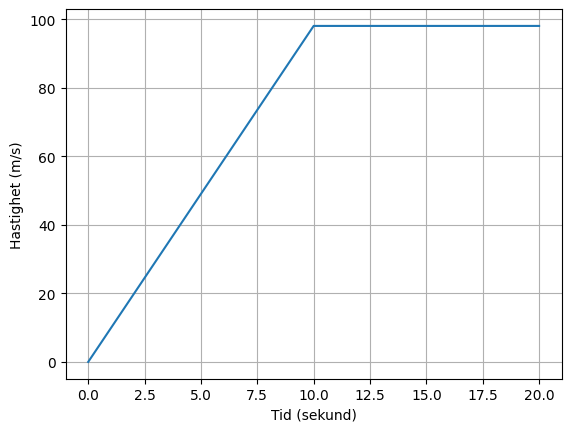

In [10]:
t = np.linspace(0, 20, 501)
import matplotlib.pyplot as plt
plt.plot(t, hastighet(t))
plt.xlabel("Tid (sekund)")
plt.ylabel("Hastighet (m/s)")
plt.grid(True)

[her](../resources/images/fallskjermhopper.png) kan du se hvordan plottet skal se ut.